In [1]:
import hces
import pandas as pd
df = hces.load()
org = pd.read_parquet('../../hces-2023-24/data/sec-4.2-CSQ.parquet')

df['num_hhmem_publicedu'] = org.loc[df.index, 'num_hhmem_publicedu'].fillna(0)
df['num_hhmem_privedu'] = org.loc[df.index, 'num_hhmem_privedu'].fillna(0)
df['n_enrolled'] = df['num_hhmem_privedu'] + df['num_hhmem_publicedu']

df[hces.FOOD_COLS] = df[hces.FOOD_COLS] / df['family_size'].values.reshape(-1, 1)
df['food'] = df[hces.FOOD_COLS].sum(axis=1)  # Food per capita

In [2]:
# PDS

xdf = df.copy()
xdf['treat'] = (df['has_benefited_from_pmgky'] == 'yes') | (df['used_ration_card'] == 'yes')

psm = hces.propensity_score_match(xdf, num_cols=['family_size', 'n_children', 'n_elderly'],                                  
                                  cat_cols=['sector', 'nss_region', 'employed_annual', 'max_income_from', 'hoh_religion', 'caste'])
psm = psm[psm['label'].isin(['D', 'E'])]

In [5]:
import seaborn as sns

<Axes: xlabel='food', ylabel='Percent'>

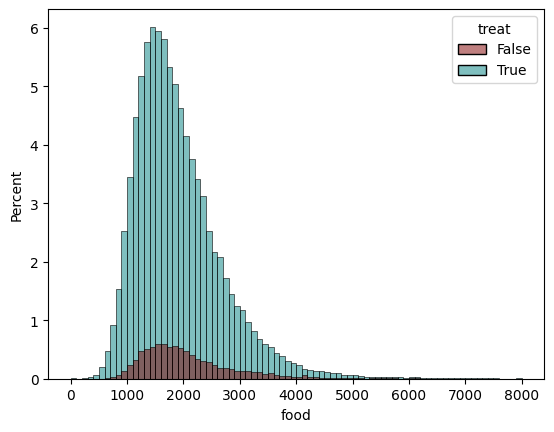

In [39]:
sns.histplot(psm[psm['food'] < 8000], bins=50, x="food", hue="treat",  multiple="layer", palette={True: "teal", False: "maroon"}, weights="multiplier", alpha=0.5, stat='percent', binwidth=100, element="bars")

In [19]:
# total food
hces.compare(psm, ['treat'], ['food'])

,food
treat,
False,2082.716019
True,1914.051963


In [20]:
# total education per enrolled student
xx = psm[psm['n_enrolled'] > 0].copy()

xx[hces.EDU_COLS] /= xx['n_enrolled'].values.reshape(-1, 1)
xx['education'] = xx[hces.EDU_COLS].sum(axis=1)
hces.compare(xx, ['treat'], ['education'])

,education
treat,
False,549.072392
True,445.190597


<Axes: xlabel='education', ylabel='Percent'>

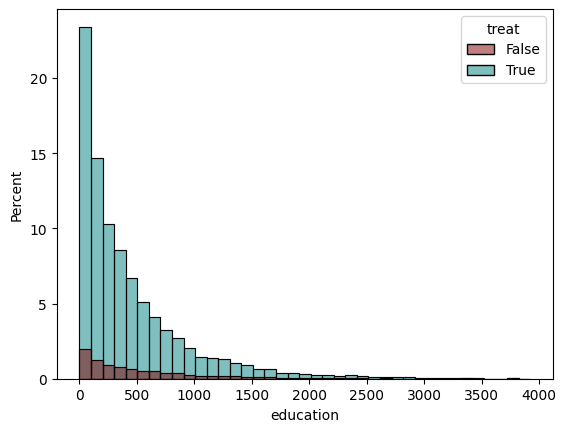

In [44]:
sns.histplot(xx[xx['education'] < 4000], bins=50, x="education", hue="treat",  multiple="layer", palette={True: "teal", False: "maroon"}, weights="multiplier", alpha=0.5, stat='percent', binwidth=100, element="bars")

In [45]:
hces.compare(psm, ['treat'], hces.FOOD_COLS)


,cereals,pulses,sugar_salt,dairy,veg,fruits,meat,oil,spice,bev,cooked,processed
treat,,,,,,,,,,,,
False,302.433600,89.634223,40.613581,391.190822,253.173038,121.592838,194.315558,127.020002,141.294220,105.955171,178.213694,137.279271
True,209.958501,87.431324,33.932536,281.129468,259.329915,121.186758,249.144029,116.917815,144.100724,102.971309,178.493109,129.456475


In [46]:
hces.compare(xx, ['treat'], hces.EDU_COLS)

,books_1st,books_2nd,stationery,fees,coaching,edu_other
treat,,,,,,
False,96.067407,3.643881,63.794899,299.444970,74.323953,11.797283
True,75.728682,2.993603,54.157149,221.687698,80.869901,9.753565


In [47]:
# Health insurance safetynet

xdf = df[df['is_hospitalization'] == 4].copy()
xdf['treat'] = xdf['is_hhmem_pmjay'] == 1

psm = hces.propensity_score_match(xdf, num_cols=['family_size', 'n_children', 'n_elderly'],                                  
                                  cat_cols=['sector', 'nss_region', 'employed_annual', 'max_income_from', 'hoh_religion', 'caste'])
psm = psm[psm['label'].isin(['D', 'E'])]

In [48]:
# total food
hces.compare(psm, ['treat'], ['food'])

,food
treat,
False,2089.998281
True,1971.631853


<Axes: xlabel='food', ylabel='Percent'>

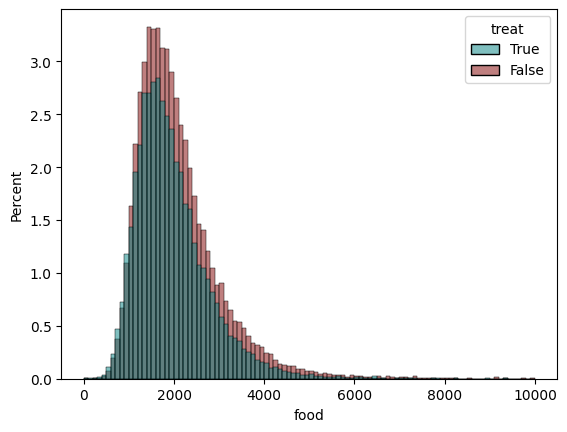

In [58]:
sns.histplot(psm[psm['food'] < 10000], bins=50, x="food", hue="treat",  multiple="layer", palette={True: "teal", False: "maroon"}, weights="multiplier", alpha=0.5, stat='percent', binwidth=100, element="bars", hue_order=[True, False])

In [53]:
# total education per enrolled student
xx = psm[psm['n_enrolled'] > 0].copy()

xx[hces.EDU_COLS] /= xx['n_enrolled'].values.reshape(-1, 1)
xx['education'] = xx[hces.EDU_COLS].sum(axis=1)
hces.compare(xx, ['treat'], ['education'])

,education
treat,
False,522.355248
True,478.735427


<Axes: xlabel='education', ylabel='Percent'>

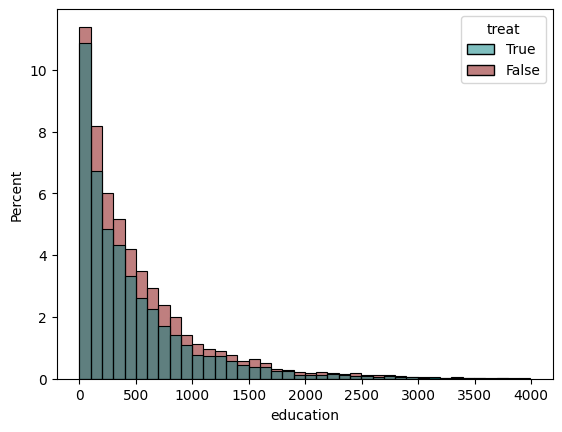

In [61]:
sns.histplot(xx[xx['education'] < 4000], bins=50, x="education", hue="treat",  multiple="layer", palette={True: "teal", False: "maroon"}, weights="multiplier", stat='percent', binwidth=100, element="bars", hue_order=[True, False])

In [62]:
hces.compare(psm, ['treat'], hces.FOOD_COLS)

,cereals,pulses,sugar_salt,dairy,veg,fruits,meat,oil,spice,bev,cooked,processed
treat,,,,,,,,,,,,
False,227.890090,94.066522,38.807940,369.896321,274.765192,128.581160,223.965024,126.453891,155.362769,116.392413,192.582507,141.234452
True,220.630795,84.071187,34.599182,289.657904,282.950397,122.086646,258.038860,123.506197,151.053089,102.243637,178.238680,124.555278


In [63]:
hces.compare(xx, ['treat'], hces.EDU_COLS)

,books_1st,books_2nd,stationery,fees,coaching,edu_other
treat,,,,,,
False,91.333036,3.822747,59.494057,278.264905,79.595563,9.844941
True,70.693282,2.816561,56.832998,204.381379,133.580819,10.430388


In [64]:
# Midday meals
xdf = df[(df['num_hhmem_publicedu'] > 0) & (df['n_children'] > 0)].copy()
xdf['treat'] = xdf['n_school_meals'] > 0

psm = hces.propensity_score_match(xdf, num_cols=['family_size', 'n_children', 'n_elderly'],                                  
                                  cat_cols=['sector', 'nss_region', 'employed_annual', 'max_income_from', 'hoh_religion', 'caste'])
psm = psm[psm['label'].isin(['D', 'E'])]

In [65]:
# total food
hces.compare(psm, ['treat'], ['food'])

,food
treat,
False,1775.872585
True,1823.305727


<Axes: xlabel='food', ylabel='Percent'>

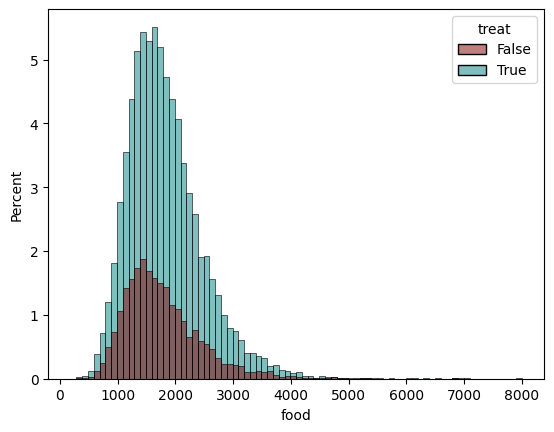

In [67]:
sns.histplot(psm[psm['food'] < 10000], bins=50, x="food", hue="treat",  multiple="layer", palette={True: "teal", False: "maroon"}, weights="multiplier", alpha=0.5, stat='percent', binwidth=100, element="bars", hue_order=[False, True])

In [68]:
# total education per enrolled student
xx = psm[psm['n_enrolled'] > 0].copy()

xx[hces.EDU_COLS] /= xx['n_enrolled'].values.reshape(-1, 1)
xx['education'] = xx[hces.EDU_COLS].sum(axis=1)
hces.compare(xx, ['treat'], ['education'])

,education
treat,
False,231.293190
True,195.770487


<Axes: xlabel='education', ylabel='Percent'>

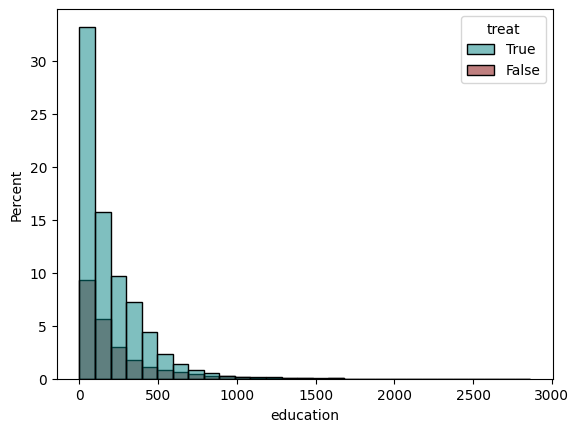

In [70]:
sns.histplot(xx[xx['education'] < 3000], bins=50, x="education", hue="treat",  multiple="layer", palette={True: "teal", False: "maroon"}, weights="multiplier", stat='percent', binwidth=100, element="bars", hue_order=[True, False])

In [15]:
hces.compare(psm, ['treat'], hces.FOOD_COLS)

,cereals,pulses,sugar_salt,dairy,veg,fruits,meat,oil,spice,bev,cooked,processed
treat,,,,,,,,,,,,
False,201.277165,82.473360,34.194408,305.453837,235.713635,113.136033,210.565635,111.248988,130.954448,97.239807,123.594220,130.021048
True,205.670653,76.326094,31.616677,250.035381,230.077707,97.399551,210.677794,108.818003,125.921073,84.640404,275.699036,126.423353


In [71]:
hces.compare(xx, ['treat'], hces.EDU_COLS)

,books_1st,books_2nd,stationery,fees,coaching,edu_other
treat,,,,,,
False,42.308493,1.832558,43.106871,76.943798,61.618847,5.482624
True,32.192282,1.415135,38.080560,41.967248,77.540988,4.574273


In [17]:
# LPG Subsidy

xdf = df[df['energy_source_cooking'] == 'LPG'].copy()
xdf['treat'] = xdf['received_subsidy_lpg']  == 1

psm = hces.propensity_score_match(xdf, num_cols=['family_size', 'n_children', 'n_elderly'],                                  
                                  cat_cols=['sector', 'nss_region', 'employed_annual', 'max_income_from', 'hoh_religion', 'caste'])
psm = psm[psm['label'].isin(['D', 'E'])]

In [18]:
# total food
hces.compare(psm, ['treat'], ['food'])

,food
treat,
False,2242.645304
True,2146.442743


In [19]:
# total education per enrolled student
xx = psm[psm['n_enrolled'] > 0].copy()

xx[hces.EDU_COLS] /= xx['n_enrolled'].values.reshape(-1, 1)
xx['education'] = xx[hces.EDU_COLS].sum(axis=1)
hces.compare(xx, ['treat'], ['education'])

,education
treat,
False,620.394106
True,678.971397


In [20]:
hces.compare(psm, ['treat'], hces.FOOD_COLS)

,cereals,pulses,sugar_salt,dairy,veg,fruits,meat,oil,spice,bev,cooked,processed
treat,,,,,,,,,,,,
False,227.210307,95.171207,42.294939,470.616542,271.577913,145.278722,220.884526,124.834758,154.969048,133.429844,195.888093,160.489404
True,226.188276,94.152583,37.893306,414.356307,272.479167,138.513797,232.992071,121.154522,142.509911,124.429947,189.428693,152.344162


In [21]:
hces.compare(xx, ['treat'], hces.EDU_COLS)

,books_1st,books_2nd,stationery,fees,coaching,edu_other
treat,,,,,,
False,110.910767,3.718316,64.541684,360.030606,66.334689,14.858045
True,119.725361,3.868117,74.356532,361.709605,107.527722,11.784061


In [22]:
# Free electricity

xdf = df[df['energy_source_lighting'].str.startswith('electricity')].copy()
xdf['treat'] = xdf['received_free_electricity']  == 1

psm = hces.propensity_score_match(xdf, num_cols=['family_size', 'n_children', 'n_elderly'],                                  
                                  cat_cols=['sector', 'nss_region', 'employed_annual', 'max_income_from', 'hoh_religion', 'caste'])
psm = psm[psm['label'].isin(['D', 'E'])]

In [23]:
# total food
hces.compare(psm, ['treat'], ['food'])

,food
treat,
False,2253.461141
True,2559.825736


In [24]:
# total education per enrolled student
xx = psm[psm['n_enrolled'] > 0].copy()

xx[hces.EDU_COLS] /= xx['n_enrolled'].values.reshape(-1, 1)
xx['education'] = xx[hces.EDU_COLS].sum(axis=1)
hces.compare(xx, ['treat'], ['education'])

,education
treat,
False,574.223412
True,648.485214


In [25]:
hces.compare(psm, ['treat'], hces.FOOD_COLS)

,cereals,pulses,sugar_salt,dairy,veg,fruits,meat,oil,spice,bev,cooked,processed
treat,,,,,,,,,,,,
False,237.468825,99.449775,36.920603,333.065466,289.976942,149.599067,255.606935,133.344393,159.575464,130.975071,269.255767,158.222833
True,263.396033,106.462175,36.049053,366.425310,283.091977,179.703404,292.420975,116.120956,173.128010,179.168209,383.967395,179.892239


In [26]:
hces.compare(xx, ['treat'], hces.EDU_COLS)

,books_1st,books_2nd,stationery,fees,coaching,edu_other
treat,,,,,,
False,95.022615,3.293774,62.359313,291.984054,108.923028,12.640628
True,117.213677,5.674617,73.237510,391.089771,38.932296,22.337343
